In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.close('all')

In [2]:
# המודל
N_ROWS = 50
SEATS = list("ABCDEF")
BLOCKERS = {"A":{"B","C"}, "B":{"C"}, "C":set(),
            "F":{"E","D"}, "E":{"D"}, "D":set()}

def exp_time(mean, rng):
    return 0.0 if mean <= 0 else rng.exponential(mean)

def simulate(order, rng):
    front_clear = np.zeros(N_ROWS + 1)
    seated = {r:set() for r in range(1, N_ROWS+1)}
    for (row, seat) in order:
        start = front_clear[row]
        t = exp_time(0.5, rng)
        k = len(seated[row].intersection(BLOCKERS[seat]))
        if k > 0:
            t += exp_time(0.25 + 0.5*k, rng)
        finish = start + t
        for r in range(row, N_ROWS+1):
            if front_clear[r] < finish: front_clear[r] = finish
            else: break
        seated[row].add(seat)
    return float(np.max(front_clear))


In [3]:
# השיטות השונות של העלייה למטוס
def order_random(rng):
    p=[(r,s) for r in range(1,N_ROWS+1) for s in SEATS]
    rng.shuffle(p); return p

def order_front_to_back(rng):
    out=[]
    for r in range(1, N_ROWS+1):
        ss=SEATS.copy(); rng.shuffle(ss)
        out.extend((r,s) for s in ss)
    return out

def order_back_to_front(rng):
    out=[]
    for r in range(N_ROWS,0,-1):
        ss=SEATS.copy(); rng.shuffle(ss)
        out.extend((r,s) for s in ss)
    return out

def order_steffen():
    out=[]; groups=[["A","F"],["B","E"],["C","D"]]
    for seats in groups:
        for parity in [0,1]:
            for r in range(N_ROWS,0,-1):
                if r % 2 == parity:
                    for s in seats: out.append((r,s))
    return out


In [4]:
# הרצת הסימולציה לכל שיטה
def run(num_runs=100, seed=20250822):
    rng=np.random.default_rng(seed)
    gens={"Random":order_random,
          "Front-to-Back":order_front_to_back,
          "Back-to-Front":order_back_to_front,
          "Steffen":lambda _rng: order_steffen()}
    rows=[]
    for name, gen in gens.items():
        for i in range(num_runs):
            local=np.random.default_rng(rng.integers(0, 2**32-1))
            rows.append({"run":i+1,"method":name,
                         "total_minutes":simulate(gen(local), local)})
    return pd.DataFrame(rows)

results = run(100)

LABELS = {
    "Random": "Random",
    "Front-to-Back": "Front to back",
    "Back-to-Front": "Back to front",
    "Steffen": "Steffen boarding method"
}
results_disp = results.copy()
results_disp["method"] = results_disp["method"].map(LABELS)

# סיכום תוצאות
summary = (results.groupby("method")["total_minutes"]
           .agg(["count","mean","std","min","max"]
           ).sort_values("mean")).reset_index()
summary["method"] = summary["method"].map(LABELS)

In [5]:
# חישוב רווח סמך לכל שיטה
def ci95(x):
    m=np.mean(x); s=np.std(x, ddof=1); n=len(x)
    half=stats.t.ppf(0.975, n-1)*s/np.sqrt(n)
    return m, m-half, m+half

cis=[]
for m_orig in results["method"].unique():
    arr = results.loc[results["method"]==m_orig, "total_minutes"].values
    mean, lo, hi = ci95(arr)
    cis.append({"method": LABELS[m_orig], "mean": mean, "ci95_low": lo, "ci95_high": hi})
cis = pd.DataFrame(cis)

cis = cis.merge(summary[["method","mean"]], on="method", how="left", suffixes=("", "_sortkey"))
cis = cis.sort_values("mean_sortkey").drop(columns=["mean_sortkey"])


In [6]:
#ANOVA
anova_model = ols('total_minutes ~ C(method)', data=results).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
eta_sq = float(anova_table.loc['C(method)', 'sum_sq'] / anova_table['sum_sq'].sum())

# Kruskal Wallis
kw_stat, kw_p = stats.kruskal(
    *[results.loc[results["method"]==m, "total_minutes"].values
      for m in results["method"].unique()]
)

In [7]:
#מבחן TUKEY HSD (post hoc)
tukey = pairwise_tukeyhsd(endog=results["total_minutes"], groups=results["method"], alpha=0.05)
_tsum = tukey.summary()
tukey_df = pd.DataFrame(_tsum.data[1:], columns=_tsum.data[0])
tukey_df["group1"] = tukey_df["group1"].map(LABELS)
tukey_df["group2"] = tukey_df["group2"].map(LABELS)

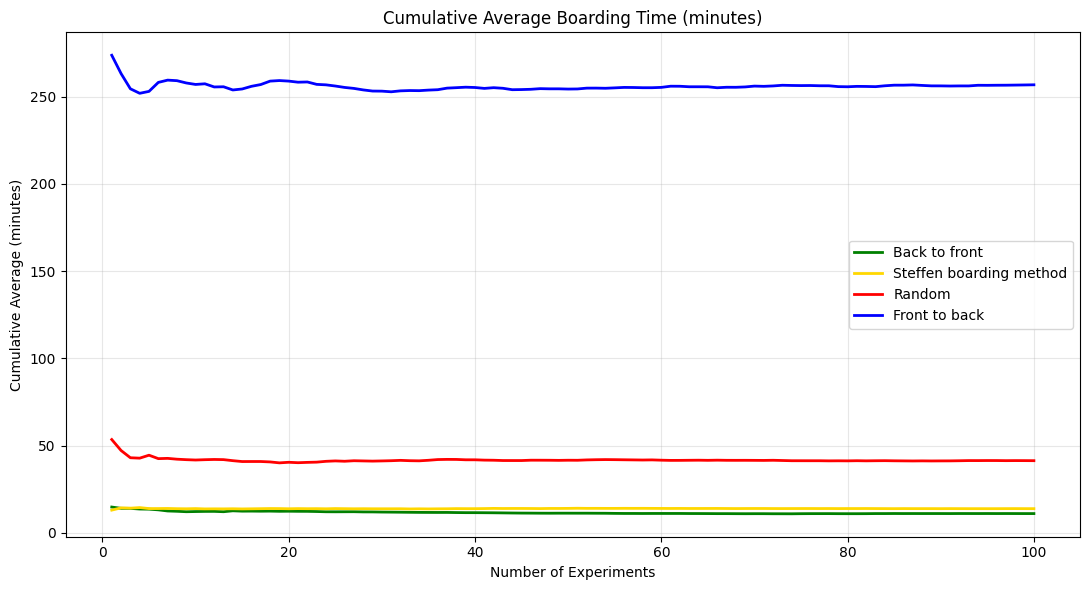

Saved cumulative-average plot to: /content/cumulative_means.png


In [8]:
# גרף ממוצע מצטבר
def make_pivot_disp(df_disp):
    return (df_disp.pivot(index="run", columns="method", values="total_minutes")
            .sort_index())

def plot_cumulative_means(pivot_disp, save_path=None, show=True, order_for_legend=None):
    cm = pivot_disp.copy()
    for col in cm.columns:
        cm[col] = cm[col].expanding().mean()
    colors = {"Random":"red","Front to back":"blue","Back to front":"green",
              "Steffen boarding method":"gold"}
    fig = plt.figure(figsize=(11,6))
    cols = order_for_legend if order_for_legend is not None else list(cm.columns)
    for name in cols:
        plt.plot(cm.index, cm[name], label=name, linewidth=2, color=colors.get(name))
    plt.title("Cumulative Average Boarding Time (minutes)")
    plt.xlabel("Number of Experiments")
    plt.ylabel("Cumulative Average (minutes)")
    plt.grid(True, alpha=0.3)
    plt.legend(); plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=200)
    if show: plt.show()
    return cm, fig

pivot_disp = make_pivot_disp(results_disp)
order_for_legend = summary.sort_values("mean")["method"].tolist()

png_cm_path = os.path.abspath("cumulative_means.png")
plot_cumulative_means(pivot_disp, save_path=png_cm_path, show=True, order_for_legend=order_for_legend)
print("Saved cumulative-average plot to:", png_cm_path)

In [9]:
# Anova
anova_clean = sm.stats.anova_lm(anova_model, typ=2).reset_index().rename(columns={"index":"Source"})
anova_clean["Source"] = anova_clean["Source"].replace({"C(method)": "Boarding method"})
anova_clean = anova_clean.rename(columns={"PR(>F)": "p value"})
anova_clean["F"] = anova_clean["F"].round(3)
anova_clean["p value"] = anova_clean["p value"].apply(lambda x: f"{x:.2e}")
anova_clean["sum_sq"] = anova_clean["sum_sq"].round(2)

REVERSE_LABELS = {v: k for k, v in LABELS.items()}
best2_disp = summary.sort_values("mean").head(2)["method"].tolist()
m1_disp, m2_disp = best2_disp[0], best2_disp[1]
m1_key, m2_key = REVERSE_LABELS[m1_disp], REVERSE_LABELS[m2_disp]

x = results.loc[results["method"] == m1_key, "total_minutes"].values
y = results.loc[results["method"] == m2_key, "total_minutes"].values

In [10]:
# t test
t_stat, p_two_sided = stats.ttest_ind(x, y, equal_var=False)
p_t_one_sided = (p_two_sided / 2) if (t_stat < 0) else (1 - p_two_sided / 2)

# Mann - Whitney U test
u_stat, p_u = stats.mannwhitneyu(x, y, alternative="less")

In [11]:
print("\nSummary (minutes):")
print(summary.round(2).to_string(index=False))
print("\n95% CIs (minutes):")
print(cis.round(2).to_string(index=False))
print("\nANOVA:")
print(anova_clean.to_string(index=False))
print(f"\nKruskal Wallis: H={kw_stat:.3f}, p={kw_p:.2e};  Effect size (eta squared)={eta_sq:.3f}")
print("\nTukey HSD:")
print(tukey_df.sort_values("p-adj").to_string(index=False))
print("\nPairwise tests for the two best methods:")
print(f"Best two (by mean): {m1_disp} vs {m2_disp}")
# t test + u test
alpha = 0.05 #רמת מובהקות
mean1, mean2 = float(np.mean(x)), float(np.mean(y))

# t-test (one-sided)
print("\nOne-sided t-test:")
print(f"  Compared: {m1_disp} vs {m2_disp}")
print(f"  Sample means: {m1_disp}={mean1:.3f}, {m2_disp}={mean2:.3f}")
print(f"  t={t_stat:.3f}, p={p_t_one_sided:.3e}")
if p_t_one_sided < alpha:
    print(f"  Decision: Reject H0 (= evidence that {m1_disp} is faster than {m2_disp})")
else:
    print(f"  Decision: Fail to reject H0 (= no sufficient evidence that {m1_disp} is faster than {m2_disp})")

# Mann - Whitney U (one-sided)
print("\nOne-sided Mann-Whitney U test:")
print(f"  Compared: {m1_disp} vs {m2_disp}")
print(f"  U={u_stat:.1f}, p={p_u:.3e}")
if p_u < alpha:
    print(f" Decision: Reject H0 (= evidence that {m1_disp} tends to be faster than {m2_disp})")
else:
    print(f" Decision: Fail to reject H0 (= no sufficient evidence that {m1_disp} is faster than {m2_disp})")




Summary (minutes):
                 method  count   mean   std    min    max
          Back to front    100  11.06  1.82   7.66  19.51
Steffen boarding method    100  13.88  1.74  10.32  17.95
                 Random    100  41.38  5.40  30.46  56.63
          Front to back    100 256.77 16.66 218.10 297.60

95% CIs (minutes):
                 method   mean  ci95_low  ci95_high
          Back to front  11.06     10.70      11.42
Steffen boarding method  13.88     13.53      14.22
                 Random  41.38     40.30      42.45
          Front to back 256.77    253.46     260.07

ANOVA:
         Source     sum_sq    df         F  p value
Boarding method 4185985.01   3.0 17821.758 0.00e+00
       Residual   31004.24 396.0       NaN      nan

Kruskal Wallis: H=358.253, p=2.44e-77;  Effect size (eta squared)=0.993

Tukey HSD:
       group1                  group2  meandiff  p-adj     lower     upper  reject
Back to front           Front to back  245.7035 0.0000  242.4750  248.9319    